### Instruccions

L'exàmen consta de tres preguntes. La 1a pregunta és obligatòria i pots triar quines dues preguntes de les tres restants contestar.

Per a poder contestar les preguntes, heu de descarregar el fitxer `data.csv` del campus virtual.


In [4]:
import numpy as np
import pandas as pd
from tqdm.notebook import trange, tqdm
import heapq
import math

In [5]:
data = pd.read_csv("data.csv")
num_movies = data.nunique()['movie_id']

In [6]:
def build_counts_table(df):
    """
    Retorna un dataframe on les columnes són els `movie_id`, les files `user_id` i els valors
    la valoració que un usuari ha donat a una peli d'un `movie_id`
    
    :param df: DataFrame original 
    :return: DataFrame descrit adalt
    """
    
    # Apliquem la funció pivot a user_id i movie_id per tenir les puntuacions
    return df.pivot_table(values='rating', index='user_id', columns='movie_id')

In [7]:
def similarity_matrix_2(DataFrame):
    """
    Retorna una matriu de mida M x M on cada posició 
    indica la similitud entre usuaris (resp. ítems).
    Substitueix els nand per 0.

    :return : Matriu numpy de mida M x M amb les similituds.
    """
    # Substituim els NaN per 0 per tal de fer les operacions
    data = DataFrame.fillna(0).values
    
    # Normalitzem els vectors
    norms = np.linalg.norm(data, axis=1, keepdims=True)

    # Substituïm les normes zero per 1 per evitar divisió per zero
    normalized_data = np.divide(data, norms, where=(norms != 0))
    
    # Calculem la matriu de similituds (producte escalar entre vectors)
    similarity_matrix = np.matmul(normalized_data, normalized_data.T)
    
    return similarity_matrix

In [8]:
def normalize(z):
    z_exp = [math.exp(i) for i in z]
    sum_z_exp = sum(z_exp)
    softmax = [round(i / sum_z_exp, 4) for i in z_exp]
    return softmax

In [9]:
def find_similar_users(DataFrame, sim_mx, userID, m):
    similarity_vector = sim_mx[userID]
    scores = []
    
    for user, similarity in enumerate(similarity_vector):
        if(user == userID):
            continue
            
        # Si a la nostra llista de scores encara queda espai, afegim directament
        if len(scores) < m:
            heapq.heappush(scores, (similarity, user))
        # Sino afegim l'element i eliminem el més petit
        else:
            heapq.heappushpop(scores, (similarity, user))
    
    # Normalitzem els valors de les similituds
    similarities, users = zip(*scores)
    similarities = normalize(similarities)
    scores = list(zip(similarities, users))

    # Retornem les tuples ordenades pels users
    return sorted(scores, key=lambda x: x[1])

In [10]:
def weighted_average(DataFrame, user, sim_mx, m):
    """    
    :param DataFrame: dataframe que conté totes les dades
    :param user: usuari al qual fem la recomanació
    :param sim_mx: similarity_matrix
    :param m: nombre d'usuaris semblants a tenir en compte per les recomanacions
    :return: diccionari {peli_id: score predit}
    """
    # Busquem els m usuaris semblants
    similar_users = find_similar_users(DataFrame, sim_mx, user, m)

    # Separem les similarities dels users
    similarities, users = zip(*similar_users)

    # Deixem similarities com una matriu vertical
    similarities = np.array(similarities).reshape(-1, 1)
    
    # Ens quedem amb les puntuacions d'aquests usuaris i
    # eliminem les columnes on tot son NaNs
    selected_users = DataFrame.loc[list(users)].dropna(axis=1, how="all")

    # Calculem la suma de les similarities
    # Utilitzem notna() per tenir True/False i obtenir el recompte
    sim_sum = (selected_users.notna() * similarities).sum(axis=0)
    
    # Multipliquem les similarities pels users del df i fem la suma per pelis
    total = (selected_users * similarities).sum(axis=0)

    # Normalitzem els valors
    total_sim_sum = total / sim_sum

    # Retornem un diccionari del tipus {peli_id: score}
    return total_sim_sum.to_dict()

In [11]:
def getRecommendationsUser(DataFrame, user, sim_mx, n, m):
    """    
    :param DataFrame: dataframe que conté totes les dades
    :param user: usuari al qual fem la recomanació
    :param sim_mx: similarity_function
    :param n: nombre de pelis a recomanar
    :param m: nombre d'usuaris semblants a tenir en compte per les recomanacions
    :return : dataframe de pel·licules amb els scores.
    """
    # Obtenim les puntuacions predites per cada peli
    predicted_scores = weighted_average(DataFrame, user, sim_mx, m)

    # Obtenim les pelis que ja ha puntuat l'usuari
    user_rated_movies = DataFrame.loc[user].dropna().index.tolist()

    # Eliminem del diccionari les pelis que l'usuari ja ha puntuat
    filtered_scores = {movie: score for movie, score in predicted_scores.items() if movie not in user_rated_movies}

    # Agafem les n millors pelis
    top_n_movies = sorted(filtered_scores.items(), key=lambda item: item[1], reverse=True)[:n]
    
    # Convertim el resultat a un DataFrame
    recommendations = pd.DataFrame(top_n_movies, columns=["movie_id", "predicted_score"])
    
    return recommendations

### Pregunta 1 (obligatòria)

Executa el recomanador (fent servir el mètode `similarity_matrix_2`) per trobar les recomanacions per a un usuari amb `user_id = 123`, que tingui en compte els 150 usuaris més semblants a ell i retorni 5 pel·lícules. Modifica el recomanador (si és necessari) perquè només mostri pel·lícules amb una puntuació mitjana superior a 3.5.

In [12]:
user_id = 123
df_counts = build_counts_table(data)
sim = similarity_matrix_2(df_counts)
user_prediction = getRecommendationsUser(df_counts, user_id, sim, 5, 150)
user_prediction

,movie_id,predicted_score
0,2711,5.0
1,2940,5.0
2,116,5.0
3,189,5.0
4,214,5.0


In [3]:
# Necessitem veure a quines pel·lícules corresponen aquests movie_id
user_prediction['title'] = ""
for index, movie in user_prediction.iterrows():
    movie['title'] = data.loc[data['movie_id'] == movie['movie_id']].iloc[0]['title']
    user_prediction.loc[index] = movie

user_prediction

NameError: name 'user_prediction' is not defined

In [25]:
# Alternativa
# Seleccionar només les columnes 'movie_id' i 'title' de la taula original
movie_titles = data[['movie_id', 'title']].drop_duplicates()

# Unir (merge) els dos DataFrames utilitzant 'movie_id' com a clau
result = user_prediction.merge(movie_titles, on='movie_id', how='left')
result = result.drop(columns=['title_x']).rename(columns={'title_y': 'title'})

# El resultat contindrà les columnes 'movie_id', 'predicted_score' i 'title'
display(result)

,movie_id,predicted_score,title
0,2711,5.0,My Life So Far (1999)
1,2940,5.0,Gilda (1946)
2,116,5.0,Anne Frank Remembered (1995)
3,189,5.0,Reckless (1995)
4,214,5.0,Before the Rain (Pred dozhdot) (1994)


### Pregunta 2

Busca quins són el **15 gèneres** de pel·lícules més valorats (en puntuació mitjana) pels homes. 

Busca quins són el **15 gèneres** de pel·lícules més valorats (en puntuació mitjana) per les dones. 

Mostra un gràfic o taula comparativa que mostri les diferències (en puntuació mitjana) entre homes i dones per totst els gèneres que has trobat.

### Pregunta 3

Fes un gràfic de la distribució d'edats dels usuaris que han valorat les pel·lícules amb una puntuació de 4 o més.

In [2]:
# Necessitem plt
import matplotlib as mpl
import matplotlib.pyplot as plt

In [15]:
good_ratings = data[data['rating'] >= 4]
ratings_by_user = good_ratings.groupby('user_id').size()

active_users = ratings_by_user.index[ratings_by_user > 1]

# Filtrar les dades només pels usuaris actius
active_good_ratings = good_ratings[good_ratings['user_id'].isin(active_users)]

# Obtenir la distribució d'edats
age_distribution = active_good_ratings['age'].value_counts().sort_index()

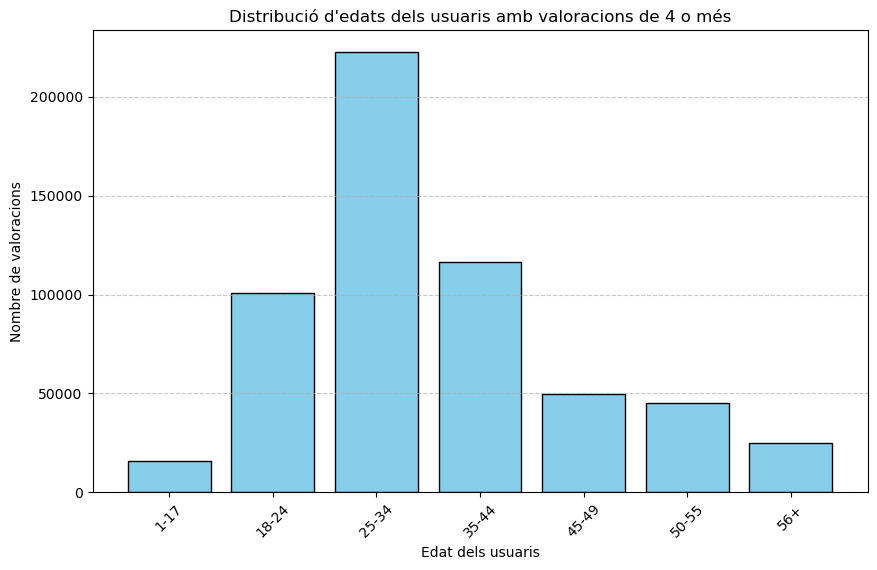

In [16]:
age_bins = {
    1: '1-17',
    18: '18-24',
    25: '25-34',
    35: '35-44',
    45: '45-49',
    50: '50-55',
    56: '56+'
}

age_distribution.index = age_distribution.index.map(age_bins)

plt.figure(figsize=(10, 6))
plt.bar(age_distribution.index, age_distribution.values, color='skyblue', edgecolor='black')
plt.xlabel('Edat dels usuaris')
plt.ylabel('Nombre de valoracions')
plt.title('Distribució d\'edats dels usuaris amb valoracions de 4 o més')
plt.xticks(age_distribution.index, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Pregunta 4

Identifica les pel·lícules amb més variabilitat en les valoracions entre diferents grups d'edat. Mostra les cinc pel·lícules amb més variabilitat i explica breument el resultat. 

In [17]:
# Tots els grups d'edat l'han d'haver valorat (ens desfem de les pel·lícules que no)
# Refem l'anterior línia
mean_ratings = data.pivot_table('rating', index='title', columns='age', aggfunc='mean')
mean_ratings = mean_ratings.dropna(axis=0)
mean_ratings['variació'] = mean_ratings.std(axis=1)

In [18]:
mean_ratings

age,1,18,25,35,45,50,56,variació
title,,,,,,,,
'Night Mother (1986),2.000000,4.666667,3.423077,2.904762,3.833333,3.555556,4.333333,0.891933
'Til There Was You (1997),3.500000,2.500000,2.666667,2.900000,2.333333,2.500000,2.666667,0.385724
"'burbs, The (1989)",4.500000,3.244444,2.652174,2.818182,2.545455,3.208333,2.666667,0.679126
...And Justice for All (1979),3.000000,3.428571,3.724138,3.657143,4.100000,3.551724,3.928571,0.356648
10 Things I Hate About You (1999),3.745455,3.415020,3.432950,3.102941,3.258065,3.629630,4.000000,0.303850
...,...,...,...,...,...,...,...,...
"Young Poisoner's Handbook, The (1995)",5.000000,4.047619,3.483871,3.333333,3.500000,3.500000,4.000000,0.581523
Young Sherlock Holmes (1985),3.000000,3.629630,3.448485,3.257143,3.125000,3.297297,3.388889,0.208473
Your Friends and Neighbors (1998),4.000000,3.516129,3.296296,3.400000,2.750000,3.000000,4.000000,0.469569


In [19]:
# Ara podem ordenar segons la variabilitat (que hem considerat la desviació estàndard)
sorted_by_diff = mean_ratings.sort_values(by='variació', ascending=False)
# I ens quedem amb els 5 primers
sorted_by_diff.head(5)

age,1,18,25,35,45,50,56,variació
title,,,,,,,,
Freedom for Us (À nous la liberté ) (1931),1.0,1.000000,3.750000,4.0,3.666667,4.333333,5.000000,1.599334
Last Summer in the Hamptons (1995),5.0,1.000000,2.000000,3.2,5.000000,3.000000,2.666667,1.474438
"Ballad of Ramblin' Jack, The (2000)",1.0,3.666667,4.200000,4.0,4.000000,4.000000,1.000000,1.459289
Plunkett & MaCleane (1999),1.0,2.600000,3.052632,4.0,1.000000,4.000000,4.000000,1.348050
Shaft in Africa (1973),5.0,3.875000,2.428571,1.5,1.500000,2.000000,2.000000,1.326240


Aquestes resulten ser les pel·lícules les puntuacions de les quals són les que més variabilitat tenen. En altres paraules, són les pel·lícules que els grups d'edat valoren de manera més diferent (uns molt positivament i altres molt negativament). Un altre anàlisi molt diferent hauríem de fer per veure per què.

In [20]:
# És clar que moltes pel·lícules estan puntuades un sol cop, corregim el codi
threshold = 5
# Ho fem per aquelles que tinguin més d'una valoració 
ratings_by_title = data.groupby('movie_id').size()
active_titles = ratings_by_title.index[ratings_by_title > threshold]
mean_ratings = data.loc[active_titles]

mean_ratings = mean_ratings.pivot_table('rating', index='title', columns='age', aggfunc='mean')
mean_ratings = mean_ratings.dropna(axis=0)
mean_ratings['variació'] = mean_ratings.std(axis=1)

# Ara podem ordenar segons la variabilitat (que hem considerat la desviació estàndard)
sorted_by_diff = mean_ratings.sort_values(by='variació', ascending=False)

# I ens quedem amb els 5 primers
sorted_by_diff.head(5)

age,1,18,25,35,45,50,56,variació
title,,,,,,,,
"Hunt for Red October, The (1990)",2.0,5.0,4.0,4.000000,3.0,4.0,5.0,1.069045
Maverick (1994),2.0,3.5,2.0,4.000000,2.0,4.0,4.0,1.017700
"Fifth Element, The (1997)",3.0,3.0,4.0,5.000000,4.0,5.0,4.0,0.816497
"Matrix, The (1999)",4.0,3.0,4.8,4.333333,5.0,4.0,4.0,0.654169
Saving Private Ryan (1998),5.0,5.0,4.0,5.000000,5.0,5.0,4.0,0.487950
